# PED Estimation

Using the file, we will estimate the PED using **historical data** and prices by transactions. As the end product, I would envision having estimated PED for different transactions channels, segmented by i) Special Occasion Elasticity, ii) Normal Occasion Elasticity and iii) Optimistic (Low Elasticity), Medium, and Pessimistic (High Elasticity). 

Through this analysis, we want to answer the question: What is the break-even elasticity? In other words, for each elasticity estimated, what is the maximum price increase we can impose for each transaction channel without losing number of visitors. 

**Steps:**
1. I will first construct a base model - without considering holidays and special occasions, to see if we can estimate the average PED for each transaction. 
- Since the price is static historically, this creates difficulty in modeling PED for individual transaction.
- However, we can use proxy for price, eg, the difference in price across different transaction channel, to see if there is a price change, how does it nudge individuals to choose other transaction channels.
- That might be the best plan we can do to estimate PED
- Using ratio, we can isolate the effect of special occasion, since during holidays, sales of all platform are all increasing, and the ratio might be staying the same. 

2. For now, I will left out transaction channel where 0 revenue/unit prices is recorded, since we cannot estimate PED from RM 0 unit price. 

3. Then, I will segment the data according to holiday/special occasions VS non-special occasions. To simplify our analysis, we would just consider the binary case (holiday yes VS holiday no). Once the estimation of PED is possible, we will expand the model to consider more specific cases of holiday. 

In [2]:
# Import necessary libraries
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime
import statsmodels.api as sm

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## List of variables

1. Environment: Specify whether the environment is Sunway Lagoon or Lost World
- WHEN Environment = 1 THEN 'Sunway Lagoon'
- WHEN Environment = 2 THEN 'Lost World'

2. Transaction data
- Complete_QTY: Total Visitors
- OriginalAmount * Complete_QTY: Total Revenue

3. Park: Revenue Grouping (whether you are online, walk-in, bulk buying, etc)
- We should understand the different unique values available

4. TranDate: Transaction Date
- According to our EDA, we only focus on the data from 2023 to 2024 to train our model, skipping earlier years that is affected by COVID-19.

## Loading dataset

In [ ]:
# Connect to the database
con = duckdb.connect("theme_park_data.db")

# Extract the necessary information for EDA
# Transactions data, channels (revenue grouping), and type of park/environment
# Focus from 2023 to 2024

df_channel_park = con.execute("""
SELECT
    TranDate AS Transaction_Date,
    TRIM(Park) as Grouping,
    CASE
        WHEN Environment = 1 THEN 'Sunway Lagoon'
        WHEN Environment = 2 THEN 'Lost World'
    END AS Park,
    OriginalAmount AS Unit_Price,
    Complete_QTY AS No_of_Visitors,
    (OriginalAmount * Complete_QTY) AS Total_Revenue
FROM theme_park_database
WHERE Environment IN (1, 2) 
    AND Grouping IS NOT NULL
    AND TranDate >= TIMESTAMP '2023-01-01 00:00:00'
    AND TranDate < TIMESTAMP '2025-01-01 00:00:00'
""").df()

df_channel_park.head()

# Clean the 'Grouping' column directly in the dataframe
# .strip() removes spaces, .title() converts 'walk in' to 'Walk In'
df_channel_park['Grouping'] = df_channel_park['Grouping'].str.strip().str.title()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

: 

In [3]:
df_channel_park.head()

,Transaction_Date,Grouping,Park,Unit_Price,No_of_Visitors,Total_Revenue
0,2023-11-12 08:16:30,Group Function,Sunway Lagoon,0.0,0.0,0.0
1,2023-04-09 01:29:29,Tour / Hotel / Presold,Sunway Lagoon,0.0,0.0,0.0
2,2024-03-16 12:27:25,Membership,Lost World,0.0,0.0,0.0
3,2024-02-15 19:43:14,Hotspring,Lost World,12.0,1.0,12.0
4,2024-11-22 06:56:24,Hotspring,Lost World,0.0,0.0,0.0


In [4]:
# Summary statistics

# Basic Profiling & Summary Statistics

print("### Summary Statistics by Park and Channel ###")
summary_stats = df_channel_park.groupby(['Park', 'Grouping']).agg({
    'Total_Revenue': ['sum', 'mean', 'std'],
    'No_of_Visitors': ['sum', 'count'], # 'count' here tells us the number of transaction line items
    'Unit_Price': ['mean', 'max', 'min']
}).reset_index()

summary_stats

### Summary Statistics by Park and Channel ###


Park                Grouping Total_Revenue              \
                                                    sum        mean   
0      Lost World     Foc / Complimentary  0.000000e+00    0.000000   
1      Lost World          Group Function  6.486853e+06   29.166192   
2      Lost World               Hotspring  5.571817e+06    8.438873   
3      Lost World     Inter-Company/Staff  3.991750e+05   37.686461   
4      Lost World              Membership  0.000000e+00    0.000000   
5      Lost World    Tours/Hotels/Presold  7.364833e+05    0.830498   
6      Lost World              Water Park  1.374938e+07   41.000209   
7   Sunway Lagoon       B2B - Night Event  0.000000e+00    0.000000   
8   Sunway Lagoon       B2C - Night Event  0.000000e+00    0.000000   
9   Sunway Lagoon              B2C Online  0.000000e+00    0.000000   
10  Sunway Lagoon                   Event  5.598771e+05  111.953035   
11  Sunway Lagoon           Explorer Pass  0.000000e+00    0.000000   
12  Sunway Lagoon     Foc / Complimentary  0.000000e+00    0.000000   
13  Sunway Lagoon          Group Function  1.959638e+07   37.943726   
14  Sunway Lagoon           Inter-Company  2.977939e+05   65.810815   
15  Sunway Lagoon              Night Park  2.825277e+06    9.346432   
16  Sunway Lagoon                Passport  3.960000e+02    0.000516   
17  Sunway Lagoon                   Staff  1.685008e+06   62.122411   
18  Sunway Lagoon  Tour / Hotel / Presold  1.887431e+06    1.104401   
19  Sunway Lagoon                 Walk In  4.329948e+07   86.519880   
20  Sunway Lagoon        Walk In - Online  0.000000e+00    0.000000   

              No_of_Visitors           Unit_Price                  
          std            sum    count        mean     max     min  
0    0.000000    8281.000000    21964    0.000000    0.00    0.00  
1   36.049845   95382.000000   222410   31.647267  661.11 -434.26  
2   18.092995  325000.000000   660256    8.148516  115.00 -115.00  
3   38.257165    5032.000000    10592   35.972677   81.00  -76.80  
4    0.000000  504219.000000   605074    0.000000    0.00    0.00  
5    7.708353  476025.500000   886797    0.873190   88.00  -80.00  
6   48.081650  170751.000000   335349   40.224641  135.00 -135.00  
7    0.000000   40153.000000    40153    0.000000    0.00    0.00  
8    0.000000   64836.000000    64836    0.000000    0.00    0.00  
9    0.000000   42074.000000    42074    0.000000    0.00    0.00  
10  32.092857    4768.000000     5001  108.126907  121.90 -121.90  
11   0.000000   15122.000000    35852    0.000000    0.00    0.00  
12   0.000000   14087.833333    45180    0.000000    0.00    0.00  
13  52.774257  264575.000000   516459   33.465584  209.91 -209.91  
14  66.136928    2260.000000     4525   65.728522  137.14 -128.57  
15  20.980128  136438.000000   302284   13.122598   83.81  -83.81  
16   0.319657  681101.000000   767346    0.000258  198.00 -198.00  
17  62.328877   13171.000000    27124   60.297903  128.57 -128.57  
18  11.269758  658536.000000  1709009   18.932922  202.86 -143.81  
19  91.327841  246433.000000   500457   85.707066  238.10 -238.10  
20   0.000000   10138.000000    11138    0.000000    0.00    0.00

# Interpret Relative PED 

Relative PED is an econometric measure that quantifies the sensitivity of a specific transaction channel’s market share relative to a benchmark channel (the "Anchor") in response to changes in the price gap between them.

In this model, the Walk-In channel serves as the benchmark ($P_{base}$, $Q_{base}$). The Relative PED for any given channel (e.g., Online or Group Function) is defined by the following relationship:$$\text{Relative PED} = \frac{\% \Delta \left( \frac{Q_{channel}}{Q_{walk-in}} \right)}{\% \Delta \left( \frac{P_{channel}}{P_{walk-in}} \right)}$$

The "Price Gap" as a Driver: It treats the discount (the difference between the Online price and the Gate price) as the primary driver of consumer behavior.

A Relative PED of $-1.0$ indicates that for every 1% the price of a channel increases relative to the Walk-In price, the channel’s volume share decreases by 1%. This decrease represents the sum of customers who switched to buying a Walk-In ticket and customers who stopped visiting the park entirely due to the reduced value proposition. It represents the total revenue lost when there is an increase in gap of price between the walk-in price and the other transaction channel. 

# Estimate Relative PED for Sunway Lagoon

To estimate the relative PED, we need a base category, where we can compare our relative PED to. In the case of Sunway Lagoon, we will set Walk-In as the base transaction category. In this basic case, we just assume all dates are general, without considering the effect of holidays yet. We want to make sure this methodology works first, and we can then incorporate holiday/special occasion variable. 

## Benchmark = Walk In

In [30]:
# Estimate Relative PED for Sunway Lagoon
df = df_channel_park.copy()
    
# 1. Normalize Date (Strip Time)
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date']).dt.date
    
# 2. Filter: We can only examine transaction channel where the total revenue >0, total visitors >0 and price >0
# Only these rows have meaningful PED interpretation
df = df[(df['No_of_Visitors'] > 0) & (df['Unit_Price'] > 0) & (df['Park'] == 'Sunway Lagoon') & (df['Total_Revenue'] > 0)]
    
# 3. Aggregation: Daily totals per Park and Channel
daily_agg = df.groupby(['Transaction_Date', 'Park', 'Grouping']).agg({
    'No_of_Visitors': 'sum',
    'Total_Revenue': 'sum'
}).reset_index()

daily_agg['Unit_Price'] = daily_agg['Total_Revenue'] / daily_agg['No_of_Visitors']

# 4. Create the Benchmark (Walk-In) per Park
walkin_ref = daily_agg[daily_agg['Grouping'] == 'Walk In'].copy()
walkin_ref = walkin_ref.rename(columns={
    'Unit_Price': 'P_Base',
    'No_of_Visitors': 'Q_Base'
})[['Transaction_Date', 'Park', 'P_Base', 'Q_Base']]

# 5. Join and Calculate Ratios
merged = pd.merge(daily_agg, walkin_ref, on=['Transaction_Date', 'Park'])

processed = merged[
    (merged['Grouping'] != 'Walk In') & 
    (merged['Unit_Price'] > 0) & 
    (merged['P_Base'] > 0)
].copy()

# Log Ratios for Elasticity
processed['ln_Price_Ratio'] = np.log(processed['Unit_Price'] / processed['P_Base'])
processed['ln_Qty_Ratio'] = np.log(processed['No_of_Visitors'] / processed['Q_Base'])

In [31]:
# 6. NESTED LOOP: Estimate PED for each Channel in Sunway Lagoon
results = []
unique_channels = processed['Grouping'].unique()

for channel in unique_channels:
    chan_data = processed[processed['Grouping'] == channel].copy()
    chan_data = chan_data.replace([np.inf, -np.inf], np.nan).dropna(subset=['ln_Price_Ratio', 'ln_Qty_Ratio'])
    
    # Need a decent sample size for daily regression
    # Skip the transaction channel with less than 20
    if len(chan_data) < 20: 
        continue
        
    try:
        X = sm.add_constant(chan_data['ln_Price_Ratio'])
        y = chan_data['ln_Qty_Ratio']
        
        model = sm.OLS(y, X).fit()
        
        results.append({
            'Transaction_Channel': channel,
            'Relative_PED': model.params.iloc[1],
            'R_Squared': model.rsquared,
            'P_Value': model.pvalues.iloc[1],
            'Sample_Size': len(chan_data)
        })
    except:
        continue

# --- Execution ---
# Convert the list of results into a Pandas DataFrame
df_results = pd.DataFrame(results)

# Now you can use .sort_values() on the DataFrame
ped_results = df_results.sort_values(by='Relative_PED')

# Display the result
ped_results

,Transaction_Channel,Relative_PED,R_Squared,P_Value,Sample_Size
1,Inter-Company,-1.81,0.03,0.01,301
0,Group Function,-1.01,0.05,0.00,631
4,Tour / Hotel / Presold,-0.45,0.01,0.01,573
2,Night Park,-0.39,0.01,0.05,582
3,Staff,1.80,0.02,0.00,622
5,Event,3.72,0.08,0.03,62


## Revenue Impact for 1% Price Gap Increase

In [32]:
# --- Calculate Revenue Impact for a 1% Price Gap Increase ---

# 1. Get the current Total Revenue and Quantity per channel to use as a baseline
# We use the 'processed' dataframe from your earlier steps
current_baseline = processed.groupby('Grouping').agg({
    'No_of_Visitors': 'sum',
    'Total_Revenue': 'sum'
}).reset_index()

# 2. Merge baseline stats with your PED results
impact_df = pd.merge(df_results, current_baseline, left_on='Transaction_Channel', right_on='Grouping')

# 3. Calculate Impacts
# We assume a 1% increase in the Price Ratio (Gap)
price_change = 0.01 

# New Quantity based on PED: Q_new = Q_old * (1 + PED * 0.01)
impact_df['New_No_of_Visitors'] = impact_df['No_of_Visitors'] * (1 + impact_df['Relative_PED'] * price_change)

# New Price (Relative gap increase of 1%): P_new = (Total_Rev / No_Visitors) * 1.01
impact_df['Current_Avg_Price'] = impact_df['Total_Revenue'] / impact_df['No_of_Visitors']
impact_df['New_Avg_Price'] = impact_df['Current_Avg_Price'] * (1 + price_change)

# New Total Revenue
impact_df['New_Total_Revenue'] = impact_df['New_No_of_Visitors'] * impact_df['New_Avg_Price']

# Revenue Loss (or Gain) in RM
impact_df['Revenue_Impact_RM'] = impact_df['New_Total_Revenue'] - impact_df['Total_Revenue']

# 4. Clean up the final table for display
final_impact_table = impact_df[[
    'Transaction_Channel', 
    'Relative_PED', 
    'New_Total_Revenue', 
    'Revenue_Impact_RM'
]].sort_values(by='Revenue_Impact_RM')

print("Estimated Revenue Impact for a 1% Increase in Price Gap:")
# Run this to make your table look pretty for the report
pd.options.display.float_format = '{:,.2f}'.format
final_impact_table

Estimated Revenue Impact for a 1% Increase in Price Gap:


,Transaction_Channel,Relative_PED,New_Total_Revenue,Revenue_Impact_RM
0,Group Function,-1.01,"19,191,003.96","-2,947.30"
1,Inter-Company,-1.81,"295,337.65","-2,456.29"
4,Tour / Hotel / Presold,-0.45,"1,897,819.05","10,388.33"
2,Night Park,-0.39,"2,796,752.80","16,887.93"
5,Event,3.72,"566,539.34","25,751.94"
3,Staff,1.80,"1,707,280.38","46,854.17"


## Tipping Point for Price Increase

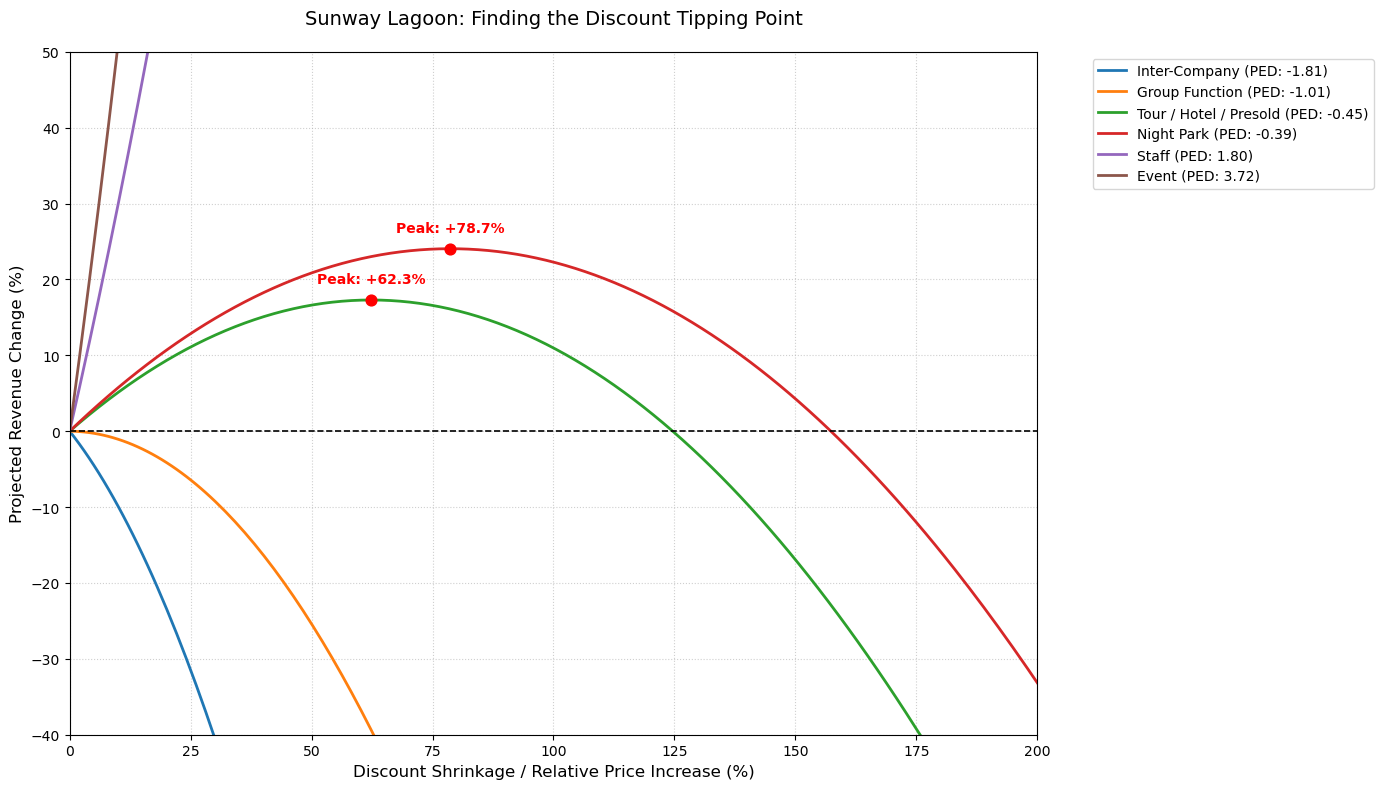


--- Sunway Lagoon Strategic Summary ---


,Channel,Current_Avg_Price,Peak_Revenue_Price,Max_Shrinkage_%,Loss_Starts_At_%
0,Tour / Hotel / Presold,18.93,30.73,62.3%,124.6%
1,Night Park,13.12,23.44,78.7%,157.3%


In [24]:
# Tour/Hotel/Presold and Night Park both have inelastic PED. I would like to find out the tipping point
# How much we could shrink the discount of those transaction channels price compared to Walk-in when we start generating losses. 

# 1. Data Setup for Sunway Lagoon
data = {
    'Transaction_Channel': ['Inter-Company', 'Group Function', 'Tour / Hotel / Presold', 'Night Park', 'Staff', 'Event'],
    'Relative_PED': [-1.806760, -1.005302, -0.445153, -0.388605, 1.803778, 3.724688],
    'Current_Revenue': [297793.9, 19596380.0, 1887431.0, 2825277.0, 1685008.0, 559877.1],
    'Mean_Price': [65.73, 33.47, 18.93, 13.12, 60.30, 108.13]
}
df = pd.DataFrame(data)

def analyze_sunway_optimization(df):
    plt.figure(figsize=(14, 8))
    
    # Range of price increases: 0% to 200% to see the full curve and breakeven
    price_changes = np.linspace(0, 2.0, 200) 
    summary_list = []
    
    for idx, row in df.iterrows():
        channel = row['Transaction_Channel']
        ped = row['Relative_PED']
        
        # Calculate % revenue change: ((1 + ΔP)(1 + PED * ΔP) - 1) * 100
        rev_pct_change = ((1 + price_changes) * (1 + ped * price_changes) - 1) * 100
        
        # We plot all channels, but focus optimization on inelastic ones
        plt.plot(price_changes * 100, rev_pct_change, label=f"{channel} (PED: {ped:.2f})", linewidth=2)
        
        # Optimization logic for Inelastic Channels (-1 < PED < 0)
        if -1 < ped < 0:
            # 1. Tipping Point (Peak)
            tp_increase = (-(1 + ped) / (2 * ped)) * 100 
            max_rev_gain = ((1 + tp_increase/100) * (1 + ped * tp_increase/100) - 1) * 100
            
            # 2. Breakeven Point (Where revenue returns to $0 gain)
            # Calculated as x = -(ped + 1) / ped
            breakeven_increase = (-(ped + 1) / ped) * 100
            
            # Highlight Peak on Graph
            plt.scatter(tp_increase, max_rev_gain, color='red', s=60, zorder=5)
            plt.annotate(f"Peak: +{tp_increase:.1f}%", 
                         (tp_increase, max_rev_gain), 
                         xytext=(0,12), textcoords="offset points", 
                         ha='center', fontsize=10, fontweight='bold', color='red')
            
            # Add to summary table
            summary_list.append({
                'Channel': channel,
                'Current_Avg_Price': f"{row['Mean_Price']:.2f}",
                'Peak_Revenue_Price': f"{row['Mean_Price'] * (1 + tp_increase/100):.2f}",
                'Max_Shrinkage_%': f"{tp_increase:.1f}%",
                'Loss_Starts_At_%': f"{breakeven_increase:.1f}%"
            })

    # Formatting
    plt.ylim(-40, 50) 
    plt.xlim(0, 200)
    plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
    plt.xlabel('Discount Shrinkage / Relative Price Increase (%)', fontsize=12)
    plt.ylabel('Projected Revenue Change (%)', fontsize=12)
    plt.title('Sunway Lagoon: Finding the Discount Tipping Point', fontsize=14, pad=20)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(summary_list)

# Execute and show table
summary_df = analyze_sunway_optimization(df)
print("\n--- Sunway Lagoon Strategic Summary ---")
summary_df

## Sunway Lagoon Result and Interpretation

1. **The "Revenue Drain" Channels (Negative RM Impact)**
- These are your highly elastic channels. We lose money if we reduce the discount here. These customers (HR departments or event organizers) are likely comparing multiple options and are very value-conscious.

- Group Function ($-2,947$ RM): This channel is Unit Elastic (PED ~ -1.0). When you raise the price by 1% (closing the gap), the drop in visitors almost perfectly cancels out the extra money you made from those who stayed. You end up with a small net loss.

- **Decision**: This is the "Sweet Spot." Don't mess with this pricing; it’s currently optimized. 

- Inter-Company ($-2,456$ RM): This is the most sensitive channel (PED -1.80). A 1% price increase causes such a large exodus of customers that you lose significant revenue.

- Decision: Do not raise prices here. These customers are likely to switch to other parks or activities immediately if the corporate discount is reduced. 

2. **The "Hidden Profit" Channels (Positive RM Impact)**
- These are the inelastic channels. You can raise prices here **compared to walk in** and actually gain revenue because the customers are "sticky. Customers who booked Sunway Lagoon Night Park and Tour/Hotel were likely to still visit the park, because they are normally staying in Sunway Hotel/have the plan for night, hence will commit to the plan.

- Night Park ($+16,887$ RM) & Tour / Hotel ($+10,388$ RM): These visitors are not price-sensitive (PED -0.38 and -0.44). Even if you make them 1% more expensive, the vast majority will still show up. The extra revenue from the remaining guests far outweighs the few guests you lose.

- Decision: These are your Profit Drivers. You have "Pricing Power" here. You can safely narrow the price gap (reduce the discount) to boost Sunway's total revenue. 

3. **The "Statistical Noise" (The Positive PEDs)**
- Staff ($+46,854$ RM) & Event ($+25,751$ RM)
- We would never obtained positive PEDs, unless it is a luxury good (where people sees the value of the goods reflected in price) or giffen good. 
- I would incline placing negative relative PED of inter-company for staff, and group function for event.
- Theme park shouldn't consider as value-storing good, as in when there is higher price, people would not value the theme park experience more as it's one-off, but would rather go away. 

# Estimate Relative PED for Lost World Tambun

## Benchmark = Water Park

In [16]:
# Estimate PED for Lost World Tambun
df = df_channel_park.copy()

# 1. Setup Date and filter for only Lost World
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date']).dt.date
lw_df = df[df['Park'] == 'Lost World'].copy()

# 2. Filter for Market Channels (Removing FOC and Membership)
excluded = ['Foc / Complimentary', 'Membership']
lw_df = lw_df[~lw_df['Grouping'].isin(excluded)]
lw_df = lw_df[(lw_df['No_of_Visitors'] > 0) & (lw_df['Total_Revenue'] > 0)]

# 3. Aggregation
daily_agg = lw_df.groupby(['Transaction_Date', 'Grouping']).agg({
    'No_of_Visitors': 'sum',
    'Total_Revenue': 'sum'
}).reset_index()
daily_agg['Unit_Price'] = daily_agg['Total_Revenue'] / daily_agg['No_of_Visitors']

daily_agg

,Transaction_Date,Grouping,No_of_Visitors,Total_Revenue,Unit_Price
0,2023-01-01,Group Function,90.90,"5,078.18",55.87
1,2023-01-01,Hotspring,288.00,"13,662.75",47.44
2,2023-01-01,Water Park,646.00,"59,703.35",92.42
3,2023-01-02,Hotspring,134.00,"4,374.40",32.64
4,2023-01-02,Water Park,299.00,"27,622.75",92.38
...,...,...,...,...,...
2455,2024-12-30,Water Park,270.00,"27,087.20",100.32
2456,2024-12-31,Group Function,136.40,"8,046.24",58.99
2457,2024-12-31,Hotspring,347.00,"15,688.00",45.21
2458,2024-12-31,Tours/Hotels/Presold,11.00,868.00,78.91


In [17]:
# 4. Create the NEW Benchmark: 'Water Park'
waterpark_ref = daily_agg[daily_agg['Grouping'] == 'Water Park'].copy()
waterpark_ref = waterpark_ref.rename(columns={
    'Unit_Price': 'P_Base',
    'No_of_Visitors': 'Q_Base'
})[['Transaction_Date', 'P_Base', 'Q_Base']]

# 5. Join and Calculate Ratios
merged = pd.merge(daily_agg, waterpark_ref, on='Transaction_Date')

# Exclude the benchmark from the test rows
processed = merged[merged['Grouping'] != 'Water Park'].copy()

# Log Ratios
processed['ln_Price_Ratio'] = np.log(processed['Unit_Price'] / processed['P_Base'])
processed['ln_Qty_Ratio'] = np.log(processed['No_of_Visitors'] / processed['Q_Base'])

# 6. Estimate PED
results = []
unique_channels = processed['Grouping'].unique()

for channel in unique_channels:
    data = processed[processed['Grouping'] == channel].dropna()
    if len(data) < 15: continue # Sample size check
    
    X = sm.add_constant(data['ln_Price_Ratio'])
    y = data['ln_Qty_Ratio']
    model = sm.OLS(y, X).fit()
    
    results.append({
        'Park': 'Lost World',
        'Transaction_Channel': channel,
        'Relative_PED': model.params.iloc[1],
        'R_Squared': model.rsquared,
        'P_Value': model.pvalues.iloc[1],
        'Sample_Size': len(data)
    })
    
results = pd.DataFrame(results).sort_values(by='Relative_PED')
results

,Park,Transaction_Channel,Relative_PED,R_Squared,P_Value,Sample_Size
0,Lost World,Group Function,-2.23,0.13,0.00,533
1,Lost World,Hotspring,-1.07,0.24,0.00,645
3,Lost World,Inter-Company/Staff,-0.87,0.00,0.68,49
2,Lost World,Tours/Hotels/Presold,-0.38,0.00,0.18,425


## Revenue Impact for 1% Price Gap

In [18]:
# --- Calculate Revenue Impact for a 1% Price Gap Increase ---

# 1. Get the current Total Revenue and Quantity per channel to use as a baseline
# We use the 'processed' dataframe from your earlier steps
current_baseline = processed.groupby('Grouping').agg({
    'No_of_Visitors': 'sum',
    'Total_Revenue': 'sum'
}).reset_index()

# 2. Merge baseline stats with your PED results
impact_df = pd.merge(results, current_baseline, left_on='Transaction_Channel', right_on='Grouping')

# 3. Calculate Impacts
# We assume a 1% increase in the Price Ratio (Gap)
price_change = 0.01 

# New Quantity based on PED: Q_new = Q_old * (1 + PED * 0.01)
impact_df['New_No_of_Visitors'] = impact_df['No_of_Visitors'] * (1 + impact_df['Relative_PED'] * price_change)

# New Price (Relative gap increase of 1%): P_new = (Total_Rev / No_Visitors) * 1.01
impact_df['Current_Avg_Price'] = impact_df['Total_Revenue'] / impact_df['No_of_Visitors']
impact_df['New_Avg_Price'] = impact_df['Current_Avg_Price'] * (1 + price_change)

# New Total Revenue
impact_df['New_Total_Revenue'] = impact_df['New_No_of_Visitors'] * impact_df['New_Avg_Price']

# Revenue Loss (or Gain) in RM
impact_df['Revenue_Impact_RM'] = impact_df['New_Total_Revenue'] - impact_df['Total_Revenue']

# 4. Clean up the final table for display
final_impact_table = impact_df[[
    'Transaction_Channel', 
    'Relative_PED', 
    'New_Total_Revenue', 
    'Revenue_Impact_RM'
]].sort_values(by='Revenue_Impact_RM')

print("Estimated Revenue Impact for a 1% Increase in Price Gap:")
# Run this to make your table look pretty for the report
pd.options.display.float_format = '{:,.2f}'.format
final_impact_table

Estimated Revenue Impact for a 1% Increase in Price Gap:


,Transaction_Channel,Relative_PED,New_Total_Revenue,Revenue_Impact_RM
0,Group Function,-2.23,"5,835,105.34","-74,015.38"
1,Hotspring,-1.07,"5,107,628.18","-4,375.47"
2,Inter-Company/Staff,-0.87,"310,719.29",374.29
3,Tours/Hotels/Presold,-0.38,"693,655.03","4,234.98"


## Tipping Point for Price Increase

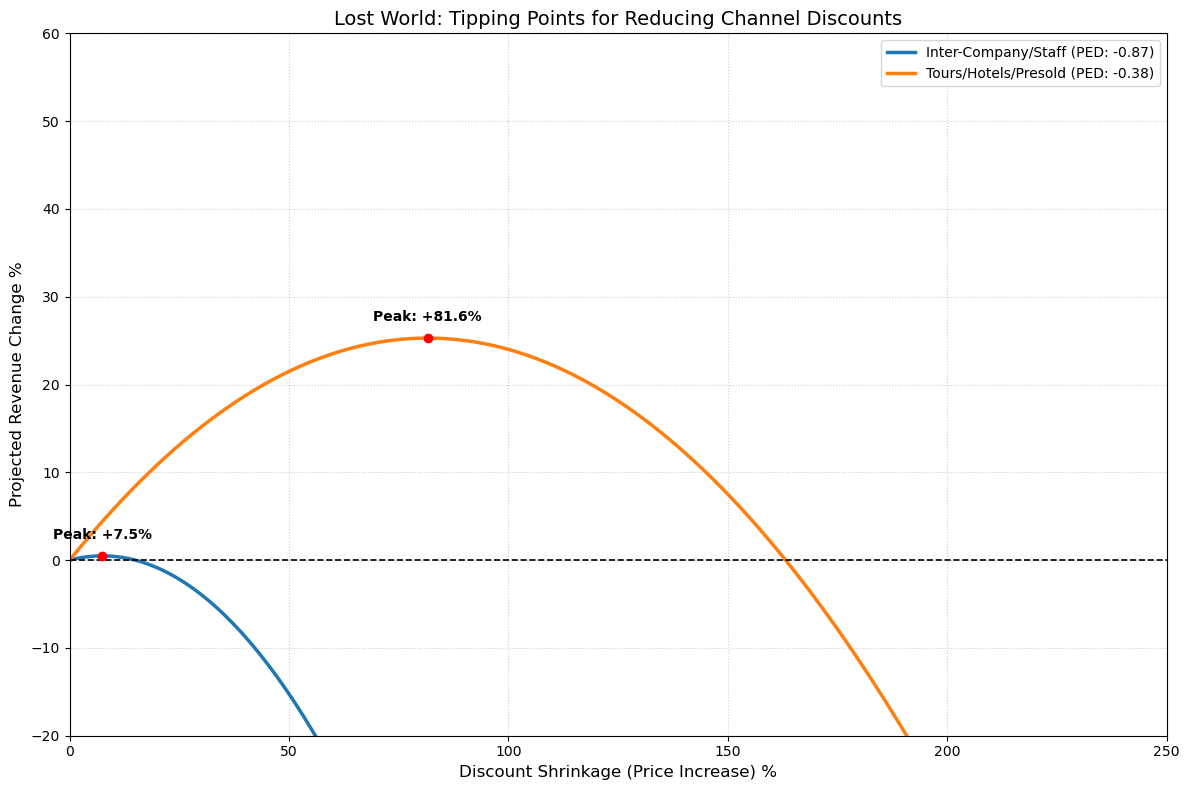


--- Lost World Strategic Summary ---


,Channel,Current_Avg_Price,Peak_Revenue_Price,Max_Shrinkage_%,Breakeven_Shrinkage_%
0,Inter-Company/Staff,37.69,40.51,7.50,14.90
1,Tours/Hotels/Presold,0.83,1.51,81.60,163.20


In [25]:
# 1. Data Setup from your Latest Lost World Table
# Note: Scientific notation converted to full numbers
data_lw = {
    'Transaction_Channel': ['Group Function', 'Hotspring', 'Inter-Company/Staff', 'Tours/Hotels/Presold'],
    'Relative_PED': [-2.23, -1.07, -0.87, -0.38], # Relative PED values
    'Current_Revenue': [6486853, 5571817, 399175, 736483],
    'Mean_Price': [29.17, 8.44, 37.69, 0.83]
}
df_lw = pd.DataFrame(data_lw)

def analyze_lwt_shrinkage(df):
    plt.figure(figsize=(12, 8))
    
    # Range of discount shrinkage (price increase) from 0% to 250%
    price_changes = np.linspace(0, 2.5, 250) 
    summary = []
    
    for idx, row in df.iterrows():
        channel = row['Transaction_Channel']
        ped = row['Relative_PED']
        
        # Revenue % change formula: ((1 + ΔP)(1 + PED * ΔP) - 1) * 100
        rev_pct_change = ((1 + price_changes) * (1 + ped * price_changes) - 1) * 100
        
        # We focus on the inelastic channels where we can safely shrink the discount
        if -1 < ped < 0:
            plt.plot(price_changes * 100, rev_pct_change, label=f"{channel} (PED: {ped})", linewidth=2.5)
            
            # Calculate the Peak (Tipping Point)
            tp_pct = (-(1 + ped) / (2 * ped)) * 100
            max_gain = ((1 + tp_pct/100) * (1 + ped * tp_pct/100) - 1) * 100
            
            # Calculate the Breakeven (Where you start generating net losses compared to now)
            breakeven_pct = (-(ped + 1) / ped) * 100
            
            # Annotate Peak
            plt.scatter(tp_pct, max_gain, color='red', zorder=5)
            plt.annotate(f"Peak: +{tp_pct:.1f}%", (tp_pct, max_gain), 
                         xytext=(0,12), textcoords="offset points", ha='center', fontweight='bold')
            
            summary.append({
                'Channel': channel,
                'Current_Avg_Price': row['Mean_Price'],
                'Peak_Revenue_Price': round(row['Mean_Price'] * (1 + tp_pct/100), 2),
                'Max_Shrinkage_%': round(tp_pct, 1),
                'Breakeven_Shrinkage_%': round(breakeven_pct, 1)
            })

    plt.axhline(0, color='black', linewidth=1.2, linestyle='--')
    plt.ylim(-20, 60) # Keeping the focus on the growth area
    plt.xlim(0, 250)
    plt.xlabel('Discount Shrinkage (Price Increase) %', fontsize=12)
    plt.ylabel('Projected Revenue Change %', fontsize=12)
    plt.title('Lost World: Tipping Points for Reducing Channel Discounts', fontsize=14)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return pd.DataFrame(summary)

# Generate Results
results_lwt = analyze_lwt_shrinkage(df_lw)
print("\n--- Lost World Strategic Summary ---")
results_lwt

## Lost World Tambun Result and Interpretation

1. The "Revenue Drain" Channels (Highly Elastic)
- These are your highly elastic channels. Reducing the discount here (shrinking the gap to the Water Park price) will cause a significant drop in revenue. 

- These customers are "fickle" and will switch to other activities or parks if the price moves even slightly.

- Group Function ($-2.23$ PED): This is your most price-sensitive channel.
- Analysis: With a PED of $-2.23$, a $1\%$ price increase leads to a massive $2.23\%$ drop in volume. This is a "fragile" segment likely comprised of large groups or corporate outings with very strict budget caps.
- Decision: Protect the Discount. Any attempt to shrink the discount here will result in a heavy net revenue loss.

- Hotspring ($-1.07$ PED): This channel has just crossed the threshold of Unit Elasticity.
- Analysis: At $-1.07$, the loss in visitors is slightly faster than the gain from higher prices. While not as sensitive as Group Functions, you are currently at the "Peak" of what this market will tolerate.
- Decision: Maintain Status Quo. You have no "headroom" left to increase prices here. Treat this as a fully optimized price point.

2. The "Hidden Profit" Channels (Inelastic)
- These are the segments where you still have Pricing Power. These visitors are "sticky"—likely because they are tied to a specific resort stay or a niche interest that isn't easily replaced.

- Tours / Hotels / Presold ($-0.38$ PED): This is your most resilient segment.
- Analysis: With a very low PED of $-0.38$, these guests are remarkably insensitive to price. They have likely pre-booked or are part of a travel itinerary. Even with a significant reduction in their discount, the vast majority will still visit.
- Decision: Top Profit Driver. You can safely and aggressively narrow the price gap (shrink the discount) here to boost total revenue.

- Inter-Company / Staff ($-0.87$ PED):
- Analysis: This channel is inelastic. While more sensitive than the Tours segment, you still gain more from the price increase than you lose in volume. There is mathematical "headroom" to capture extra margin here.
- Decision: Moderate Opportunity. You can afford a cautious reduction in the discount for this channel. Unlike the Hotspring or Group Function, you won't lose money on the initial phase of a price hike.

# Benchmark Volatility

The benchmark that we choose is Walk In for Sunway Lagoon and Water Park for Lost World Tambun, which is the highest sales volume in each park, and hence representing the taste of the general public. A stable benchmark represents that the park has a strong and consistent customer flow unaffected by external factors (eg, weather, occasion, etc). There, we can project that the customers are also unlikely to be affected by small price changes. This gives us the confidence to increase price for certain percentages for the park while keeping the traffic. 

To understand the benchmark volatility, due to the absence of price factors, we use Coefficient of Variation (CV), which measures the volatility of the customer traffic relative to their respective mean. A low CV indicates stability (low standard deviation). 

In [27]:
def calculate_benchmark_volatility(df):
    df = df.copy()
    df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date']).dt.date
    
    # We define our benchmarks for each park
    benchmarks = [
        ('Sunway Lagoon', 'Walk In'),
        ('Lost World', 'Water Park')
    ]
    
    vol_results = []
    
    for park, channel in benchmarks:
        # Filter for the benchmark channel in each park
        data = df[(df['Park'] == park) & (df['Grouping'] == channel)]
        
        if data.empty:
            continue
            
        # Group by day to get daily total visitor counts
        daily_counts = data.groupby('Transaction_Date')['No_of_Visitors'].sum()
        
        # We use Coefficient of Variation (CV) = Standard Deviation / Mean
        # This allows us to compare "Stability" regardless of total volume
        mean_q = daily_counts.mean()
        std_q = daily_counts.std()
        cv = std_q / mean_q if mean_q > 0 else 0
        
        # Assign a recommended benchmark based on CV
        if cv > 1.0:
            rec_ped = -1.2 # Highly volatile/fickle
        elif cv > 0.6:
            rec_ped = -0.8 # Moderate/Standard
        else:
            rec_ped = -0.5 # Very stable/steady
            
        vol_results.append({
            'Park': park,
            'Benchmark_Channel': channel,
            'Mean_Daily_Visitors': round(mean_q, 2),
            'Volatility_Index_(CV)': round(cv, 4),
            'Recommended_Benchmark_PED': rec_ped
        })
        
    return pd.DataFrame(vol_results)

# --- Execute ---
volatility_table = calculate_benchmark_volatility(df_channel_park)
volatility_table

,Park,Benchmark_Channel,Mean_Daily_Visitors,Volatility_Index_(CV),Recommended_Benchmark_PED
0,Sunway Lagoon,Walk In,380.30,0.47,-0.50
1,Lost World,Water Park,236.17,0.98,-0.80


## Interpretation

Benchmark Volatility = Customer Loyalty

1. Low (< 0.6):	-0.5
- The "Steady Core": These visitors are reliable. If they aren't scared away by a rainy day or a Tuesday, they likely won't be scared away by a 5% price hike. They are Inelastic.
- Sunway Lagoon has a higher customer loyalty compared to Lost World. This gives us higher confidence to increase the prices gap of other transaction channel relative to walk-in, without losing a lot of traffic. 

2. Moderate (0.6 - 1.0): -0.8	
- The "Standard Market": These are typical visitors. They have some loyalty but will compare prices if the gap gets too wide.
- Lost World, on the other hand, has a standard market volatility. Hence, we can still increase prices but not as rigorous as Sunway Lagoon to aintain the customer traffic. 